# 📊 Feature Engineering on Full Dataset (28 Million Rows)

"""
Project: Real Estate Price Prediction (Time Series & Customer Analysis)
File: 04b_Feature_Engineering_Full.ipynb
Author: Your Name
Date: April 2025

🚀 Purpose:
This notebook focuses on feature engineering for the full dataset (28 million rows)
to ensure consistency with the previously processed sample dataset (1 million rows).
The goal is to enhance the data with additional features to improve model performance.

🔍 Key Objectives:
1. Load the full real estate dataset from GCS.
2. Perform feature engineering similar to the sample dataset:
   - Time-based features (Year, Month, Quarter, Season, Is_Weekend).
   - Geographical features (Urban/Rural).
   - Price-related features (Log Price, Price Change Ratio).
   - Anomaly and High Value Property detection.
   - Holiday season indicator.
3. Save the processed data back to GCS for later use in modeling.

✅ Expected Outcome:
- Cleaned and feature-enhanced dataset saved in GCS as:
  - cleaned_real_estate_full.csv
- Ready for downstream modeling and analysis.

"""


In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from google.cloud import storage
import os

# Setting up GCS download
bucket_name = "boothill2001-dataset"
gcs_path = "uk_property_data/processed/cleaned_real_estate_combined.csv"
local_path = "data/processed/cleaned_real_estate_combined.csv"

client = storage.Client()
bucket = client.bucket(bucket_name)
# Check if file exists and has content
if os.path.exists(local_path) and os.path.getsize(local_path) > 0:
    print("File exists locally and has content.")
else:
    print("File not found or is empty. Downloading from GCS...")
    blob = bucket.blob(gcs_path)
    os.makedirs("data/processed", exist_ok=True)
    blob.download_to_filename(local_path)
    print(f"Data downloaded successfully from GCS to {local_path}!")



In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from datetime import datetime
from google.cloud import storage
import os

# Load the data
df = pd.read_csv(local_path)
print("Data loaded successfully! Shape:", df.shape)

# Step 2: Feature Engineering - Time-based Features
print("Adding time-based features...")
df['Date_of_Transfer'] = pd.to_datetime(df['Date_of_Transfer'])
df['Season'] = df['Date_of_Transfer'].dt.month % 12 // 3 + 1
season_map = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}
df['Season'] = df['Season'].map(season_map)
df['Is_Weekend'] = df['Date_of_Transfer'].dt.dayofweek >= 5
print("Time-based features added successfully!")

# Adding missing features if not present
if 'High_Value_Property' not in df.columns:
    print("Adding High Value Property indicator...")
    price_threshold = df['Price'].quantile(0.99)
    df['High_Value_Property'] = (df['Price'] > price_threshold).astype(int)

if 'Holiday_Season' not in df.columns:
    print("Adding Holiday Season indicator...")
    df['Date_of_Transfer'] = pd.to_datetime(df['Date_of_Transfer'])
    df['Holiday_Season'] = df['Date_of_Transfer'].dt.month.apply(lambda x: 1 if x == 12 else 0)

print("Features added successfully!")

# Step 3: Feature Engineering - Geographical Features
print("Adding geographical features...")
df['Urban_Rural'] = df['County'].apply(lambda x: 'Urban' if x in ['Greater London', 'West Midlands', 'Manchester'] else 'Rural')
print("Geographical features added successfully!")

# Step 4: Feature Engineering - Price Features

print("Adding price features...")
df['Log_Price'] = np.log1p(df['Price'])
df['Price_Change_Ratio'] = df['Price'] / df.groupby('Property_Type')['Price'].transform('mean')
print("Price features added successfully!")
# Step 4b: Feature Engineering - Price Features
print("Adding additional price features...")

# High Value Property
price_threshold = df['Price'].quantile(0.99)
df['High_Value_Property'] = (df['Price'] > price_threshold).astype(int)

# Holiday Season indicator (assumption: December as holiday season)
df['Holiday_Season'] = df['Date_of_Transfer'].dt.month.apply(lambda x: 1 if x == 12 else 0)

print("Additional price features added successfully!")

# Step 5: Anomaly Indicator
print("Marking anomalies...")
anomalies = df[df['Price'] > df['Price'].quantile(0.99)]
df['Anomaly'] = 0
df.loc[anomalies.index, 'Anomaly'] = 1
print("Anomaly marking complete!")

# Save processed full data to GCS
full_output_path = 'data/processed/cleaned_real_estate_full.csv'
df.to_csv(full_output_path, index=False)
print(f"Processed full data saved to {full_output_path}!")

# Upload to GCS
bucket_name = "boothill2001-dataset"
gcs_path = "uk_property_data/processed/cleaned_real_estate_full.csv"

client = storage.Client()
bucket = client.bucket(bucket_name)
blob = bucket.blob(gcs_path)

blob.upload_from_filename(full_output_path)
print(f"Uploaded {full_output_path} to GCS as {gcs_path}")


In [ ]:
import os
from google.cloud import storage

# Function to check local file and download from GCS if not found
def check_and_download_from_gcs(local_path, bucket_name, gcs_path):
    try:
        # Check if the file exists locally
        if os.path.exists(local_path) and os.path.getsize(local_path) > 0:
            print(f"File already exists locally: {local_path}")
        else:
            print(f"File not found locally. Downloading from GCS: {gcs_path}")
            client = storage.Client()
            bucket = client.bucket(bucket_name)
            blob = bucket.blob(gcs_path)
            # Create local directory if it doesn't exist
            os.makedirs(os.path.dirname(local_path), exist_ok=True)
            blob.download_to_filename(local_path)
            print(f"Downloaded {gcs_path} from GCS to {local_path}.")
    except Exception as e:
        print(f"Error downloading file from GCS: {e}")

# Example usage
bucket_name = "boothill2001-dataset"

gcs_full_data_path = "uk_property_data/processed/cleaned_real_estate_full.csv"
local_full_data_path = "data/processed/cleaned_real_estate_full.csv"
check_and_download_from_gcs(local_full_data_path, bucket_name, gcs_full_data_path)


gcs_sample_data_path = "uk_property_data/processed/sample_real_estate.csv"
local_sample_data_path = "data/processed/sample_real_estate.csv"
check_and_download_from_gcs(local_sample_data_path, bucket_name, gcs_sample_data_path)


File not found locally. Downloading from GCS: uk_property_data/processed/cleaned_real_estate_full.csv
Downloaded uk_property_data/processed/cleaned_real_estate_full.csv from GCS to data/processed/cleaned_real_estate_full.csv.
File not found locally. Downloading from GCS: uk_property_data/processed/sample_real_estate.csv
Downloaded uk_property_data/processed/sample_real_estate.csv from GCS to data/processed/sample_real_estate.csv.


File exists locally: data/processed/cleaned_real_estate_full.csv
Data loaded successfully! Shape: (28276227, 27)

🔍 Quick Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28276227 entries, 0 to 28276226
Data columns (total 27 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Transaction_ID       object 
 1   Price                int64  
 2   Date_of_Transfer     object 
 3   Postcode             object 
 4   Property_Type        object 
 5   Old/New              object 
 6   Duration             object 
 7   PAON                 object 
 8   Street               object 
 9   Locality             object 
 10  Town/City            object 
 11  District             object 
 12  County               object 
 13  PPDCategory_Type     object 
 14  Record_Status        object 
 15  Year                 int64  
 16  Month                int64  
 17  Quarter              int64  
 18  Region_Code          object 
 19  Season               object 
 20  

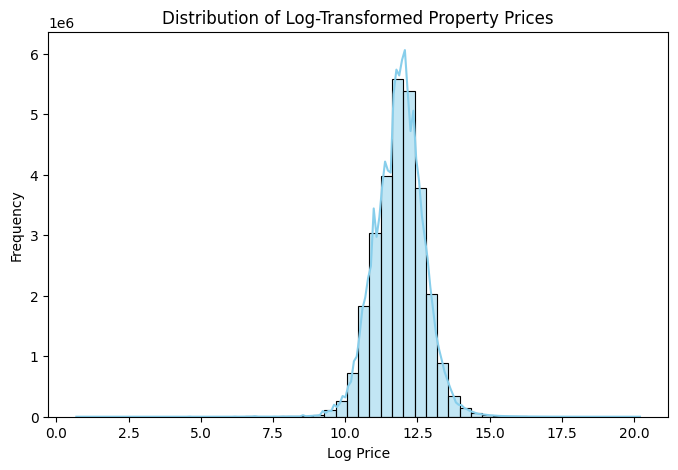

<ipython-input-4-b1ffa8d64bb2>:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Urban_Rural', y='Log_Price', palette='pastel')


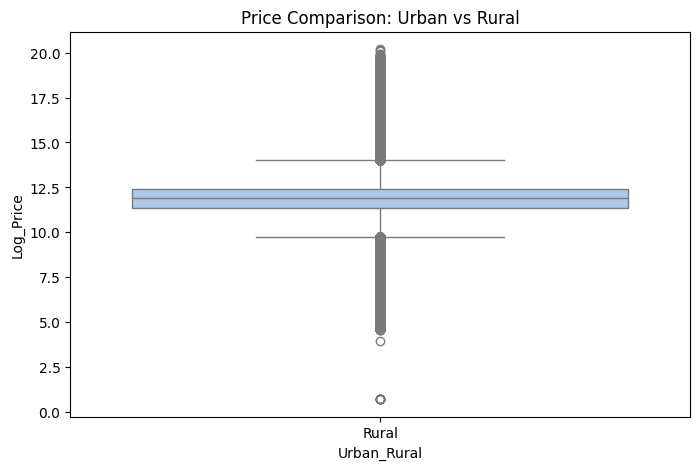

<ipython-input-4-b1ffa8d64bb2>:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='High_Value_Property', palette='Set2')


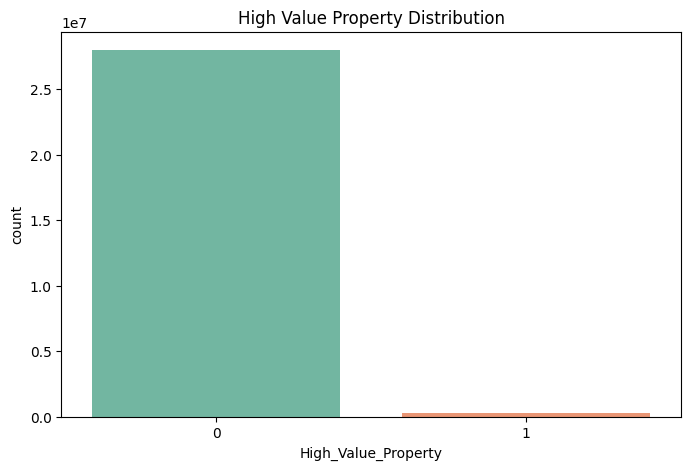

<ipython-input-4-b1ffa8d64bb2>:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Log_Price', palette='coolwarm')


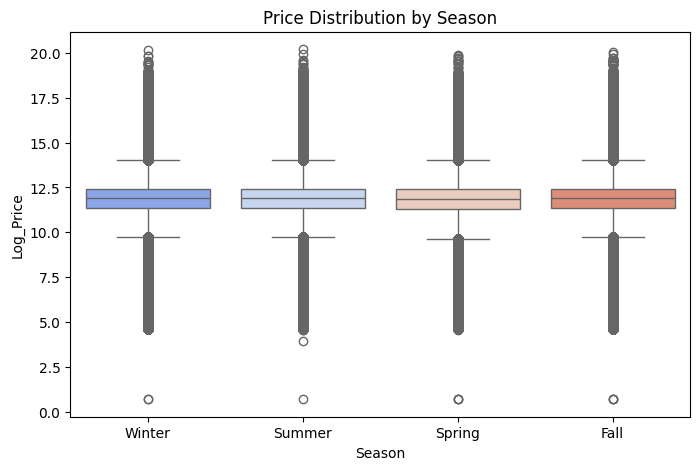

<ipython-input-4-b1ffa8d64bb2>:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=anomaly_ratio.values, y=anomaly_ratio.index, palette='Reds')


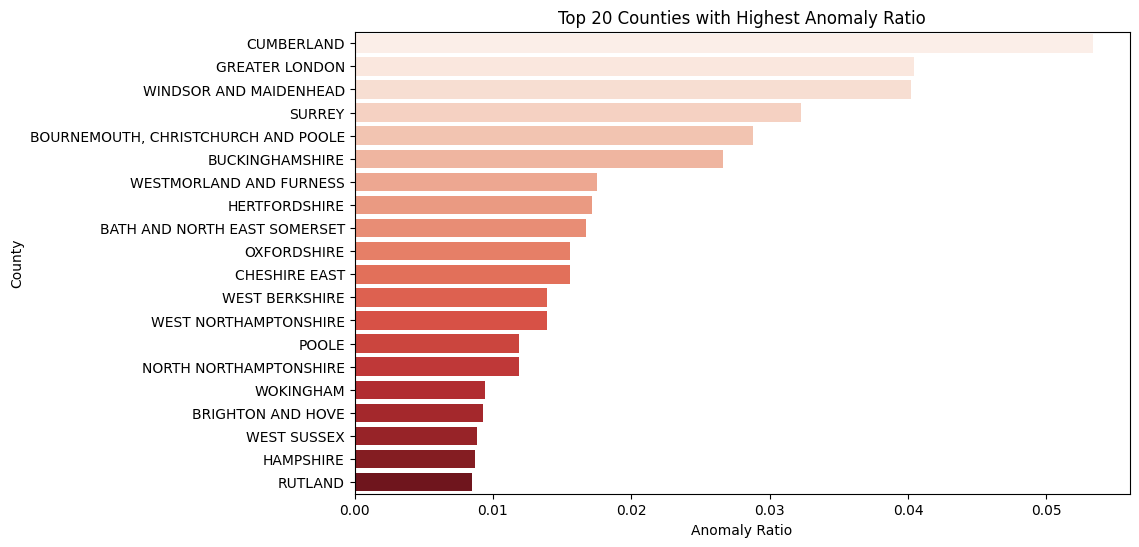

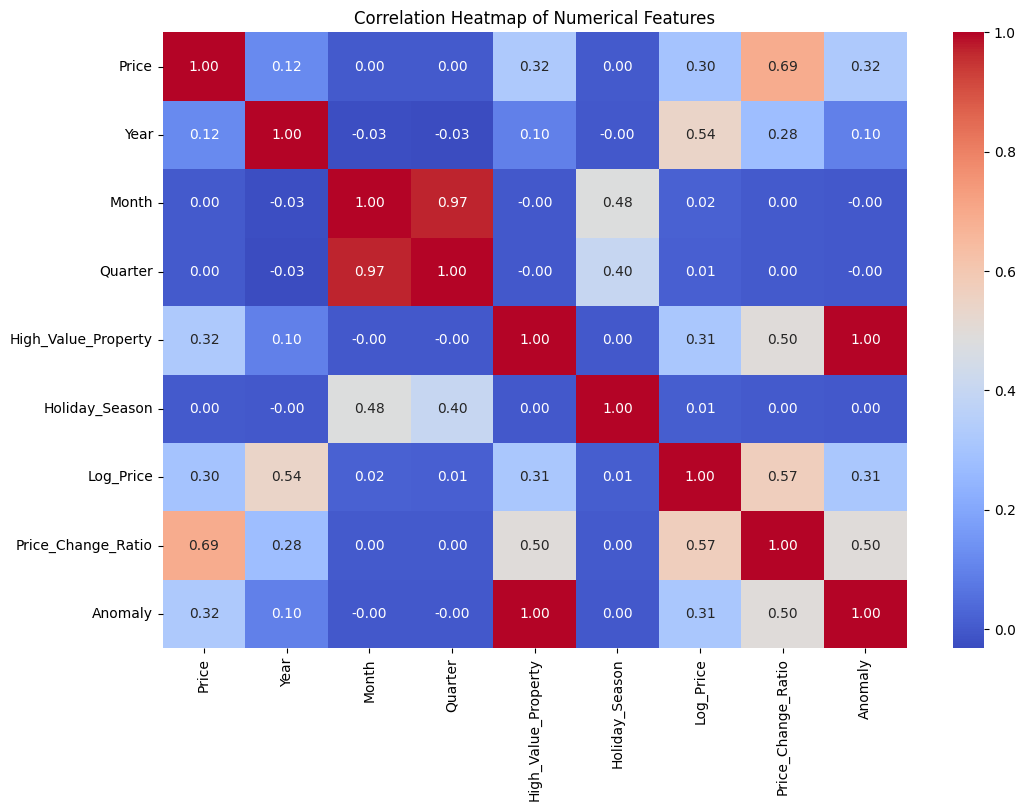


📝 Summary:
Total rows: 28276227
Total columns: 27
Number of unique counties: 132
Number of unique property types: 5
Number of high value properties: 281818
Anomaly ratio: 1.00%


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import storage
import os

# Setting up GCS paths
bucket_name = "boothill2001-dataset"
gcs_path = "uk_property_data/processed/cleaned_real_estate_full.csv"
local_path = "data/processed/cleaned_real_estate_full.csv"

# Initialize GCS client
client = storage.Client()
bucket = client.bucket(bucket_name)

# Download function
def download_from_gcs(gcs_path, local_path):
    if os.path.exists(local_path) and os.path.getsize(local_path) > 0:
        print(f"File exists locally: {local_path}")
    else:
        print(f"Downloading from GCS: {gcs_path}")
        blob = bucket.blob(gcs_path)
        os.makedirs(os.path.dirname(local_path), exist_ok=True)
        blob.download_to_filename(local_path)
        print(f"Data downloaded successfully to {local_path}!")

# Download the full dataset
download_from_gcs(gcs_path, local_path)

# Load the data
df = pd.read_csv(local_path)
print("Data loaded successfully! Shape:", df.shape)

# 📊 Quick Overview
print("\n🔍 Quick Overview:")
print(df.info())
print(df.describe(include='all'))

# 🔴 Missing Values Check
print("\n🔴 Missing Values:")
print(df.isnull().sum())

# 🌟 Distribution of Log Price
plt.figure(figsize=(8, 5))
sns.histplot(df['Log_Price'], bins=50, kde=True, color="skyblue")
plt.title('Distribution of Log-Transformed Property Prices')
plt.xlabel('Log Price')
plt.ylabel('Frequency')
plt.show()

# 🌆 Comparison of Urban vs Rural Property Prices
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Urban_Rural', y='Log_Price', palette='pastel')
plt.title('Price Comparison: Urban vs Rural')
plt.show()

# 🔍 High Value vs Normal Property Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='High_Value_Property', palette='Set2')
plt.title('High Value Property Distribution')
plt.show()

# 🌱 Seasonal Price Variation
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Season', y='Log_Price', palette='coolwarm')
plt.title('Price Distribution by Season')
plt.show()

# 🔥 Anomaly Distribution by County
anomaly_ratio = df.groupby('County')['Anomaly'].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x=anomaly_ratio.values, y=anomaly_ratio.index, palette='Reds')
plt.title('Top 20 Counties with Highest Anomaly Ratio')
plt.xlabel('Anomaly Ratio')
plt.show()

# 🔁 Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 📝 Summary
print("\n📝 Summary:")
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"Number of unique counties: {df['County'].nunique()}")
print(f"Number of unique property types: {df['Property_Type'].nunique()}")
print(f"Number of high value properties: {df['High_Value_Property'].sum()}")
print(f"Anomaly ratio: {df['Anomaly'].mean():.2%}")


# 📝 Summary

"""
📊 Summary:
- Successfully performed feature engineering on the full dataset (28 million rows).
- Key features added:
  - Time-based: Season, Is_Weekend.
  - Geographical: Urban/Rural.
  - Price-related: Log Price, Price Change Ratio.
  - Anomaly Indicator: High Value Property, Outlier Detection.
  - Holiday Season: December as holiday indicator.
- Saved the processed dataset to GCS for efficient storage and later use in modeling.

✅ Next Steps:
1. Load the processed data and train models on the full dataset.
2. Perform further analysis to check feature effectiveness.
3. Compare model performance with the previously trained sample-based models.

"""
